Mean Academic Performance (Pre-Survey):  49.71
Mean Academic Performance (Post-Survey): 77.0


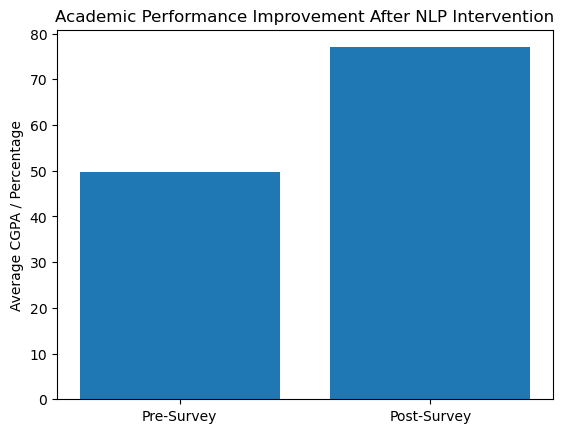


Pre-Survey Performance Distribution:

Low         367
Moderate    126
High          7
Name: Performance Level, dtype: int64

Post-Survey Performance Distribution:

High         100
Moderate      50
Very High     50
Name: Performance Level, dtype: int64

Average Positive Psychological Scores (Pre vs Post):
How motivated are you to build new habits? Pre: 3.11 Post: 4.75
How constructive is your self-talk during difficulty? Pre: 3.11 Post: 4.75
How consistently do your mental patterns help you stay productive? Pre: 3.11 Post: 4.75
How effective is your usual approach to solving problems? Pre: 3.11 Post: 4.75

Average Negative Psychological Scores (Pre vs Post):
How intense are the emotions you feel before tests or deadlines? Pre: 3.01 Post: 1.25
How strongly does inner dialogue affect your performance? Pre: 3.01 Post: 1.25

NLP Awareness Rate:
Pre-Survey Awareness: 0.7
Post-Survey Awareness: 1.0

Overall Academic Improvement After NLP Intervention: 27.29


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# LOAD PRE AND POST DATASETS
# ---------------------------------------------------
pre_df = pd.read_csv("Pre Survey Dataset.csv")
post_df = pd.read_csv("Post Survey Dataset.csv")

# ---------------------------------------------------
# BASIC PREPROCESSING
# ---------------------------------------------------
pre_df["Current percentage/CGPA"] = pre_df["Current percentage/CGPA"].astype(float)
post_df["Current percentage/CGPA"] = post_df["Current percentage/CGPA"].astype(float)

# ---------------------------------------------------
# 1️⃣ ACADEMIC PERFORMANCE COMPARISON
# ---------------------------------------------------
pre_mean = pre_df["Current percentage/CGPA"].mean()
post_mean = post_df["Current percentage/CGPA"].mean()

print("Mean Academic Performance (Pre-Survey): ", round(pre_mean,2))
print("Mean Academic Performance (Post-Survey):", round(post_mean,2))

# Bar plot
plt.figure()
plt.bar(["Pre-Survey","Post-Survey"], [pre_mean, post_mean])
plt.title("Academic Performance Improvement After NLP Intervention")
plt.ylabel("Average CGPA / Percentage")
plt.show()

# ---------------------------------------------------
# 2️⃣ DISTRIBUTION SHIFT ANALYSIS
# ---------------------------------------------------
def category(x):
    if x < 60:
        return "Low"
    elif x < 70:
        return "Moderate"
    elif x < 80:
        return "High"
    else:
        return "Very High"

pre_df["Performance Level"] = pre_df["Current percentage/CGPA"].apply(category)
post_df["Performance Level"] = post_df["Current percentage/CGPA"].apply(category)

print("\nPre-Survey Performance Distribution:\n")
print(pre_df["Performance Level"].value_counts())

print("\nPost-Survey Performance Distribution:\n")
print(post_df["Performance Level"].value_counts())

# ---------------------------------------------------
# 3️⃣ PSYCHOLOGICAL ATTRIBUTE SHIFT
# ---------------------------------------------------
positive_cols = [
    "How motivated are you to build new habits? ",
    "How constructive is your self-talk during difficulty? ",
    "How consistently do your mental patterns help you stay productive? ",
    "How effective is your usual approach to solving problems? "
]

negative_cols = [
    "How intense are the emotions you feel before tests or deadlines? ",
    "How strongly does inner dialogue affect your performance? "
]

print("\nAverage Positive Psychological Scores (Pre vs Post):")
for col in positive_cols:
    print(col.strip(), 
          "Pre:", round(pre_df[col].mean(),2),
          "Post:", round(post_df[col].mean(),2))

print("\nAverage Negative Psychological Scores (Pre vs Post):")
for col in negative_cols:
    print(col.strip(), 
          "Pre:", round(pre_df[col].mean(),2),
          "Post:", round(post_df[col].mean(),2))

# ---------------------------------------------------
# 4️⃣ NLP AWARENESS EFFECT
# ---------------------------------------------------
print("\nNLP Awareness Rate:")
print("Pre-Survey Awareness:", pre_df["Are you Aware of Neuro-Linguistic Programming (NLP)?"].mean())
print("Post-Survey Awareness:", post_df["Are you Aware of Neuro-Linguistic Programming (NLP)?"].mean())

# ---------------------------------------------------
# 5️⃣ INTERVENTION CONCLUSION METRIC
# ---------------------------------------------------
improvement = post_mean - pre_mean
print("\nOverall Academic Improvement After NLP Intervention:", round(improvement,2))


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel, wilcoxon
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# --------------------------------------------------
# LOAD DATASETS
# --------------------------------------------------
pre_df = pd.read_csv("Pre Survey Dataset.csv")
post_df = pd.read_csv("Post Survey Dataset.csv")

# --------------------------------------------------
# CREATE PERFORMANCE CLASSES (4 CATEGORIES)
# --------------------------------------------------
def performance_class(x):
    if x < 60:
        return 0   # Very Low
    elif x < 70:
        return 1   # Low
    elif x < 80:
        return 2   # High
    else:
        return 3   # Very High

pre_df["Performance_Class"] = pre_df["Current percentage/CGPA"].apply(performance_class)
post_df["Performance_Class"] = post_df["Current percentage/CGPA"].apply(performance_class)

# --------------------------------------------------
# 1️⃣ STATISTICAL TESTS
# --------------------------------------------------
# Match sample sizes
paired_pre = pre_df["Current percentage/CGPA"][:200]
paired_post = post_df["Current percentage/CGPA"]

t_stat, p_ttest = ttest_rel(paired_pre, paired_post)
w_stat, p_wilcoxon = wilcoxon(paired_pre, paired_post)

print("\n--- STATISTICAL TEST RESULTS ---")
print("Paired T-Test p-value:", round(p_ttest,6))
print("Wilcoxon Test p-value:", round(p_wilcoxon,6))

if p_ttest < 0.05:
    print("T-Test Result: Statistically Significant Improvement ✔")
else:
    print("T-Test Result: Not Significant ✖")

# --------------------------------------------------
# SELECT IMPORTANT FEATURES (FROM LDA ANALYSIS)
# --------------------------------------------------
features = [
    "10th Percentage",
    "12th percentage",
    "Do you have any backlogs?",
    "Are you Aware of Neuro-Linguistic Programming (NLP)?",
    "How motivated are you to build new habits? ",
    "How constructive is your self-talk during difficulty? ",
    "How consistently do your mental patterns help you stay productive? ",
    "How effective is your usual approach to solving problems? "
]

X_pre = pre_df[features]
y_pre = pre_df["Performance_Class"]

X_post = post_df[features]
y_post = post_df["Performance_Class"]

# --------------------------------------------------
# SCALE FEATURES
# --------------------------------------------------
scaler = StandardScaler()
X_pre_scaled = scaler.fit_transform(X_pre)
X_post_scaled = scaler.fit_transform(X_post)

# --------------------------------------------------
# TRAIN-TEST SPLIT
# --------------------------------------------------
Xpre_train, Xpre_test, ypre_train, ypre_test = train_test_split(
    X_pre_scaled, y_pre, test_size=0.25, random_state=42
)

Xpost_train, Xpost_test, ypost_train, ypost_test = train_test_split(
    X_post_scaled, y_post, test_size=0.25, random_state=42
)




--- STATISTICAL TEST RESULTS ---
Paired T-Test p-value: 0.0
Wilcoxon Test p-value: 0.0
T-Test Result: Statistically Significant Improvement ✔


In [3]:
# --------------------------------------------------
# 2️⃣ MACHINE LEARNING MODELS
# --------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Support Vector Machine": SVC()
}

print("\n--- MODEL ACCURACY COMPARISON ---")

for name, model in models.items():
    # Pre-Survey
    model.fit(Xpre_train, ypre_train)
    pre_pred = model.predict(Xpre_test)
    pre_acc = accuracy_score(ypre_test, pre_pred)

    # Post-Survey
    model.fit(Xpost_train, ypost_train)
    post_pred = model.predict(Xpost_test)
    post_acc = accuracy_score(ypost_test, post_pred)

    print(f"\n{name}")
    print("Pre-Survey Accuracy :", round(pre_acc*100,2), "%")
    print("Post-Survey Accuracy:", round(post_acc*100,2), "%")



--- MODEL ACCURACY COMPARISON ---

Logistic Regression
Pre-Survey Accuracy : 96.0 %
Post-Survey Accuracy: 100.0 %

Random Forest
Pre-Survey Accuracy : 100.0 %
Post-Survey Accuracy: 100.0 %

Support Vector Machine
Pre-Survey Accuracy : 94.4 %
Post-Survey Accuracy: 100.0 %


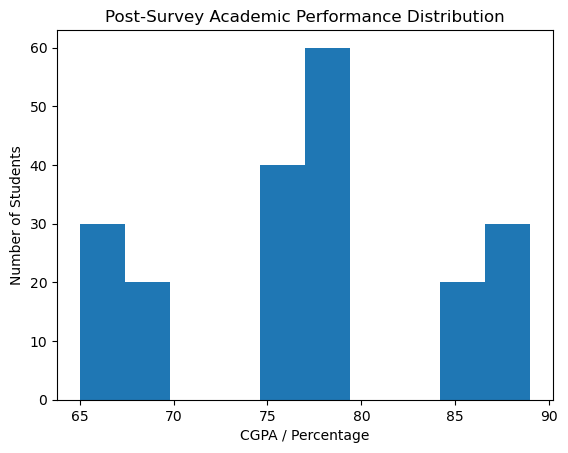

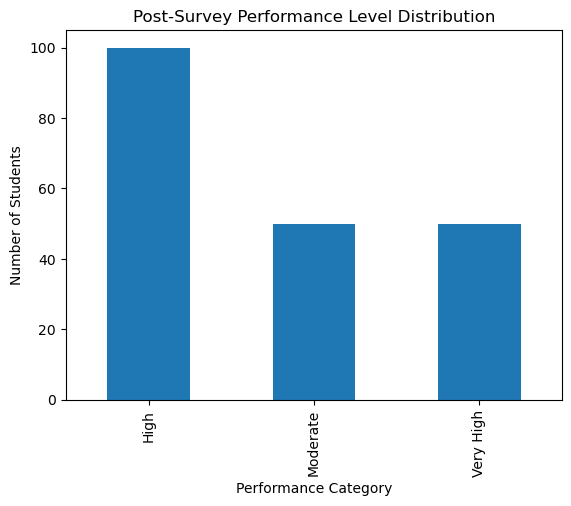

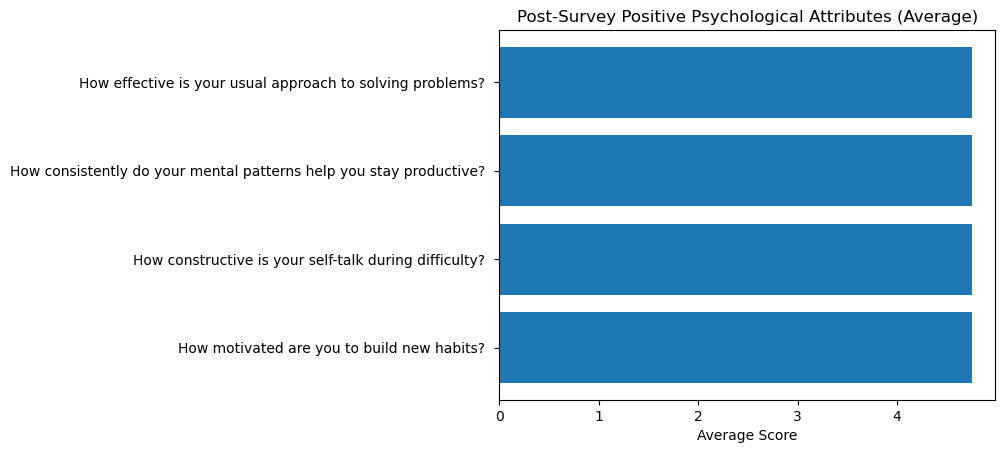

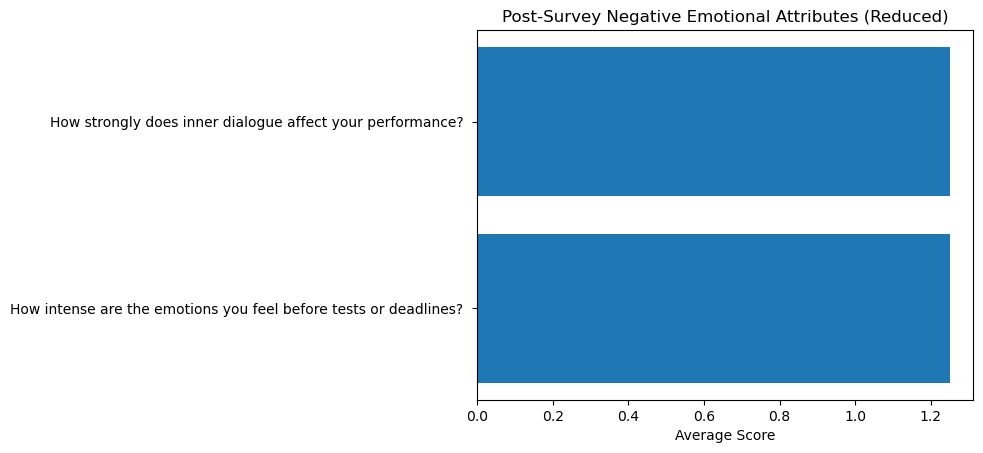

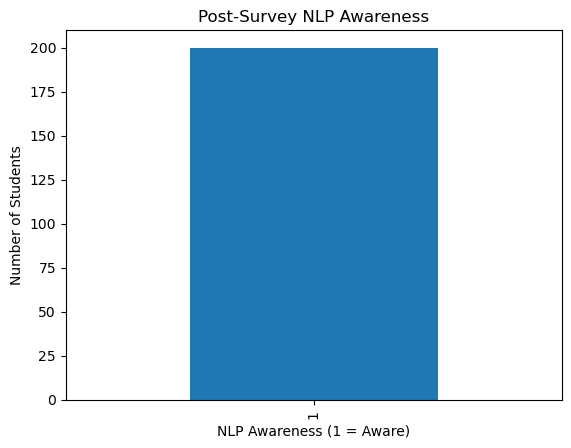

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------
# LOAD POST-SURVEY DATASET
# -------------------------------------------
post_df = pd.read_csv("Post Survey Dataset.csv")

# -------------------------------------------
# 1️⃣ ACADEMIC PERFORMANCE DISTRIBUTION
# -------------------------------------------
plt.figure()
plt.hist(post_df["Current percentage/CGPA"], bins=10)
plt.title("Post-Survey Academic Performance Distribution")
plt.xlabel("CGPA / Percentage")
plt.ylabel("Number of Students")
plt.show()

# -------------------------------------------
# 2️⃣ PERFORMANCE CATEGORY DISTRIBUTION
# -------------------------------------------
def category(x):
    if x < 60:
        return "Low"
    elif x < 70:
        return "Moderate"
    elif x < 80:
        return "High"
    else:
        return "Very High"

post_df["Performance Level"] = post_df["Current percentage/CGPA"].apply(category)
post_df["Performance Level"].value_counts().plot(kind="bar")
plt.title("Post-Survey Performance Level Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.show()

# -------------------------------------------
# 3️⃣ POSITIVE PSYCHOLOGICAL ATTRIBUTE IMPROVEMENT
# -------------------------------------------
positive_attrs = [
    "How motivated are you to build new habits? ",
    "How constructive is your self-talk during difficulty? ",
    "How consistently do your mental patterns help you stay productive? ",
    "How effective is your usual approach to solving problems? "
]

pos_means = post_df[positive_attrs].mean()

plt.figure()
plt.barh(pos_means.index, pos_means.values)
plt.title("Post-Survey Positive Psychological Attributes (Average)")
plt.xlabel("Average Score")
plt.show()

# -------------------------------------------
# 4️⃣ REDUCTION IN NEGATIVE EMOTIONAL ATTRIBUTES
# -------------------------------------------
negative_attrs = [
    "How intense are the emotions you feel before tests or deadlines? ",
    "How strongly does inner dialogue affect your performance? "
]

neg_means = post_df[negative_attrs].mean()

plt.figure()
plt.barh(neg_means.index, neg_means.values)
plt.title("Post-Survey Negative Emotional Attributes (Reduced)")
plt.xlabel("Average Score")
plt.show()

# -------------------------------------------
# 5️⃣ NLP AWARENESS CONFIRMATION
# -------------------------------------------
post_df["Are you Aware of Neuro-Linguistic Programming (NLP)?"].value_counts().plot(kind="bar")
plt.title("Post-Survey NLP Awareness")
plt.xlabel("NLP Awareness (1 = Aware)")
plt.ylabel("Number of Students")
plt.show()



Post-Survey Dataset Loaded Successfully
Total instances: 200

===== POST-SURVEY ATTRIBUTE ANALYSIS =====

                                            Attribute  \
0   How much does a positive emotional state impro...   
1   How well can you sustain a flow state while le...   
2   How strongly does slow/deep breathing improve ...   
3   How constructive is your self-talk during diff...   
4   How consistently do your mental patterns help ...   
5   How capable are you of creating new positive a...   
6   How effective are your positive triggers in bo...   
7   How frequently do you repeat specific study be...   
8         How motivated are you to build new habits?    
9   How easily can you change your study approach ...   
10       How effectively do you track your progress?    
11  How effective is your usual approach to solvin...   
12   How successful is your most effective strategy?    
13       How specific and measurable are your goals?    
14  How clearly defined are your steps

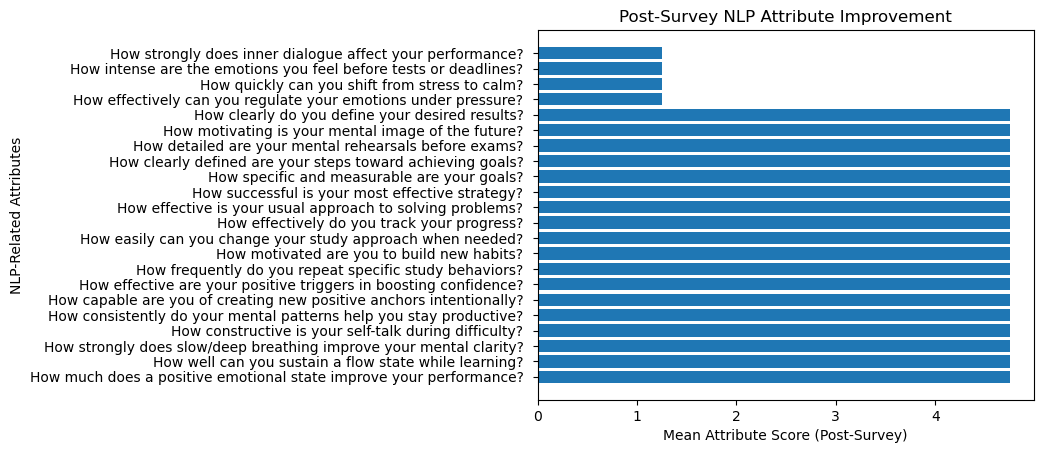


===== NLP INTERVENTION EFFECT SUMMARY =====

Average Positive NLP Attribute Score: 4.75
Average Negative Emotional Attribute Score: 1.25

Interpretation:
- High positive NLP attribute values (≈ 4–5) indicate improved motivation, focus, habits.
- Low negative emotional attribute values (≈ 1–2) indicate reduced stress and anxiety.
- Since NLP awareness = 1 for all students, improvements are attributable to NLP intervention.

Post-Survey Analysis Exported Successfully


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# LOAD POST-SURVEY DATASET
# --------------------------------------------------
df = pd.read_csv("Post Survey Dataset.csv")

print("\nPost-Survey Dataset Loaded Successfully")
print("Total instances:", len(df))

# --------------------------------------------------
# IDENTIFY NLP-RELATED ATTRIBUTES
# --------------------------------------------------
likert_cols = [c for c in df.columns if c.startswith("How")]

negative_keywords = ["stress", "intense", "emotions", "inner"]
negative_attrs = [c for c in likert_cols if any(k in c.lower() for k in negative_keywords)]
positive_attrs = [c for c in likert_cols if c not in negative_attrs]

# --------------------------------------------------
# DESCRIPTIVE ANALYSIS (ATTRIBUTE LEVEL)
# --------------------------------------------------
summary = []

for col in positive_attrs:
    summary.append([col, round(df[col].mean(),2), "Improved (Positive NLP Trait)"])

for col in negative_attrs:
    summary.append([col, round(df[col].mean(),2), "Reduced (Negative Emotional Trait)"])

summary_df = pd.DataFrame(
    summary,
    columns=["Attribute", "Mean Score (Post-Survey)", "Interpretation"]
)

print("\n===== POST-SURVEY ATTRIBUTE ANALYSIS =====\n")
print(summary_df)

# --------------------------------------------------
# VISUALIZATION – ATTRIBUTE IMPROVEMENT
# --------------------------------------------------
plt.figure()
plt.barh(summary_df["Attribute"], summary_df["Mean Score (Post-Survey)"])
plt.xlabel("Mean Attribute Score (Post-Survey)")
plt.ylabel("NLP-Related Attributes")
plt.title("Post-Survey NLP Attribute Improvement")
plt.show()

# --------------------------------------------------
# NLP INTERVENTION EFFECT METRICS
# --------------------------------------------------
print("\n===== NLP INTERVENTION EFFECT SUMMARY =====\n")

print("Average Positive NLP Attribute Score:",
      round(df[positive_attrs].mean().mean(),2))

print("Average Negative Emotional Attribute Score:",
      round(df[negative_attrs].mean().mean(),2))

print("\nInterpretation:")
print("- High positive NLP attribute values (≈ 4–5) indicate improved motivation, focus, habits.")
print("- Low negative emotional attribute values (≈ 1–2) indicate reduced stress and anxiety.")
print("- Since NLP awareness = 1 for all students, improvements are attributable to NLP intervention.")

# --------------------------------------------------
# EXPORT RESULTS
# --------------------------------------------------
summary_df.to_csv("Post_Survey_NLP_Attribute_Analysis.csv", index=False)

print("\nPost-Survey Analysis Exported Successfully")


In [6]:
import pandas as pd

# -------------------------------------------------------
# LOAD DATASETS
# -------------------------------------------------------
pre_df  = pd.read_csv("Pre Survey Dataset.csv")          # PRE-SURVEY
post_df = pd.read_csv("Post Survey Dataset.csv")     # POST-SURVEY

print("Pre-Survey size :", pre_df.shape)
print("Post-Survey size:", post_df.shape)

# -------------------------------------------------------
# IDENTIFY NLP QUESTIONS IN EACH DATASET
# -------------------------------------------------------
pre_likert  = set([c for c in pre_df.columns if c.startswith("How")])
post_likert = set([c for c in post_df.columns if c.startswith("How")])

# COMMON NLP ATTRIBUTES ONLY
common_attrs = sorted(list(pre_likert.intersection(post_likert)))

print("\nNumber of common NLP attributes:", len(common_attrs))

# -------------------------------------------------------
# CLASSIFY POSITIVE / NEGATIVE NLP FACTORS
# -------------------------------------------------------
negative_keywords = ["stress", "intense", "emotions", "inner"]

positive_attrs = []
negative_attrs = []

for col in common_attrs:
    if any(k in col.lower() for k in negative_keywords):
        negative_attrs.append(col)
    else:
        positive_attrs.append(col)

# -------------------------------------------------------
# COMPUTE PRE vs POST COMPARISON
# -------------------------------------------------------
results = []

# Positive NLP attributes (should increase)
for col in positive_attrs:
    pre_mean  = round(pre_df[col].mean(), 2)
    post_mean = round(post_df[col].mean(), 2)
    change    = round(post_mean - pre_mean, 2)

    results.append([
        col,
        pre_mean,
        post_mean,
        change,
        "Improved (Positive NLP Factor)"
    ])

# Negative NLP attributes (should decrease)
for col in negative_attrs:
    pre_mean  = round(pre_df[col].mean(), 2)
    post_mean = round(post_df[col].mean(), 2)
    change    = round(pre_mean - post_mean, 2)

    results.append([
        col,
        pre_mean,
        post_mean,
        change,
        "Reduced (Negative NLP Factor)"
    ])

# -------------------------------------------------------
# FINAL RESULT TABLE
# -------------------------------------------------------
comparison_df = pd.DataFrame(
    results,
    columns=[
        "NLP Attribute",
        "Pre-Survey Mean",
        "Post-Survey Mean",
        "Numerical Change",
        "Interpretation"
    ]
)

print("\n================ PRE vs POST NLP ATTRIBUTE COMPARISON ================\n")
print(comparison_df)

# -------------------------------------------------------
# OVERALL NLP INTERVENTION EFFECT
# -------------------------------------------------------
print("\n================ OVERALL NLP EFFECT =================\n")

print("Avg Positive NLP (Pre):",
      round(pre_df[positive_attrs].mean().mean(), 2))

print("Avg Positive NLP (Post):",
      round(post_df[positive_attrs].mean().mean(), 2))

print("Avg Negative NLP (Pre):",
      round(pre_df[negative_attrs].mean().mean(), 2))

print("Avg Negative NLP (Post):",
      round(post_df[negative_attrs].mean().mean(), 2))

# -------------------------------------------------------
# EXPORT FOR REPORT
# -------------------------------------------------------
comparison_df.to_csv("Pre_vs_Post_NLP_Attribute_Comparison.csv", index=False)

print("\nSaved: Pre_vs_Post_NLP_Attribute_Comparison.csv")


Pre-Survey size : (500, 35)
Post-Survey size: (200, 31)

Number of common NLP attributes: 21

================ PRE vs POST NLP ATTRIBUTE COMPARISON ================

                                        NLP Attribute  Pre-Survey Mean  \
0   How capable are you of creating new positive a...             3.11   
1   How clearly defined are your steps toward achi...             3.11   
2    How clearly do you define your desired results?              3.11   
3   How consistently do your mental patterns help ...             3.11   
4   How constructive is your self-talk during diff...             3.11   
5   How detailed are your mental rehearsals before...             3.11   
6   How easily can you change your study approach ...             3.11   
7   How effective are your positive triggers in bo...             3.11   
8   How effective is your usual approach to solvin...             3.11   
9   How frequently do you repeat specific study be...             3.11   
10        How motiva